# DSC 680 -  Applied Data Science #
## Project 3: Amazon Sales Performance Analysis ##
### Manoj K Kola ###

Today, I will explore the **Amazon Sales Dataset for Performance Analysis** (2019-2024) to identify which product, sales, and customer-related factors are associated with **higher sales performance**.

First, I will perform extensive data cleaning and exploratory data analysis (EDA) to understand sales trends, category performance, regional performance, and relationships between numeric fields.

Next, I will engineer a target variable representing **high sales performance** and build multiple classification models to identify which non-transactional factors (category, region, payment method, timing, and salesperson) are most associated with a high-performing order. I will use the F1 score and ROC-AUC as primary metrics and will check for class imbalance before modeling.

#### Model Interpretation

**I will also delve into model interpretation.**
This is incredibly important in industry. Often, we need to explain very technical algorithms to a non-technical audience, so any tool that can help this process should be mastered.

### Library Imports & Setup

#### 1. Core Data & Visualization Libraries

| Library | Purpose |
|---|---|
| `pandas` | Loading, cleaning, and manipulating tabular data (DataFrames) |
| `numpy` | Numerical operations and array manipulation |
| `matplotlib` | Base plotting library for charts and graphs |
| `seaborn` | High-level visualization built on matplotlib (cleaner statistical plots) |

#### 2. Train/Test Split

Splits the dataset into **training** and **testing** subsets. The model learns from the training set and is evaluated on the unseen test set to measure real-world performance.

#### 3. Preprocessing — Scaling & Encoding

- **`StandardScaler`** — Standardizes numerical features to have mean = 0 and standard deviation = 1. Prevents features with large ranges from dominating the model.
- **`OneHotEncoder`** — Converts categorical variables (e.g., `["North America", "Europe"]`) into binary columns so ML models can process them numerically.

#### 4. Pipeline & Column Transformer

- **`ColumnTransformer`** — Applies different preprocessing steps to different column types (e.g., scale numerics, encode categoricals) in one step.
- **`Pipeline`** — Chains preprocessing and model training into a single, reproducible workflow. Prevents data leakage by ensuring transformations only fit on training data.

#### 5. Evaluation Metrics

| Metric | What It Measures |
|---|---|
| `accuracy_score` | % of correct predictions overall |
| `precision_score` | Of predicted positives, how many were actually positive |
| `recall_score` | Of all actual positives, how many did the model catch |
| `f1_score` | Harmonic mean of precision & recall — useful for imbalanced data |
| `roc_auc_score` | Model's ability to distinguish between classes across thresholds |
| `confusion_matrix` | Breakdown of TP, TN, FP, FN predictions |
| `classification_report` | Summary of all above metrics per class |

#### 6. Classification Models

| Model | Strengths |
|---|---|
| `LogisticRegression` | Fast, interpretable baseline for binary classification |
| `DecisionTreeClassifier` | Intuitive, handles non-linear boundaries, prone to overfitting |
| `RandomForestClassifier` | Ensemble of trees — reduces overfitting, robust and accurate |
| `XGBClassifier` | Gradient boosting — often top performer on structured/tabular data |

#### 7. Class Imbalance Handling

**SMOTE (Synthetic Minority Oversampling Technique)** — If one class has far fewer examples than the other, the model will bias toward the majority class. SMOTE synthetically generates new minority-class samples to balance the dataset, improving recall on the rare class. Since the target used here is built from a median split, the classes should already be close to balanced, but SMOTE is still applied for consistency and to correct any imbalance introduced by the train/test split.

In [1]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import preprocessing tools for scaling and encoding data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Import tools to apply different preprocessing steps to columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Import machine learning classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import the XGBoost classifier
from xgboost import XGBClassifier

# Import SMOTE to balance the dataset by oversampling the minority class
from imblearn.over_sampling import SMOTE

# Set a consistent visual style for all plots
sns.set_style("whitegrid")

### Load & Preview Data

Reads the Amazon sales dataset from an Excel file into a pandas DataFrame. `.head()` returns the first 5 rows to verify that the data loaded correctly and to inspect the column structure.

In [2]:
# Load the Amazon sales dataset into a DataFrame
df = pd.read_excel("amazon_sales_dataset_2019_2024_corrected.xlsx")

# Display the first 5 rows to preview the data
df.head()

,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity Sold,Unit Price,Discount (%),Salesperson,Payment Method,Order Status,Total Sales,Profit Margin
0,576ca8db-ad1a-4aa8-9c3a-89102555f200,2019-01-01,48aa940a-5cb5-4103-8d89-19c10fd26aaf,Stephanie Garcia,South America,Home & Kitchen,Speak,9,484.46,21.33,Johnny Marshall,Debit Card,Returned,3430.12,1193.53
1,b7154d7e-f369-4a81-80b1-d36b23cc0420,2019-01-01,8de3545c-78e6-4962-ace5-02e37fe1ce91,Jacob Morales,South America,Books,If,10,179.28,6.43,Bradley Howe,Gift Card,Pending,1677.52,583.70
2,b2852522-fbaa-43fa-b165-bd10e0035591,2019-01-02,6ac41f61-acf6-4e46-8b70-ad00ce01c9d0,John Carroll,North America,Sports,Big,6,185.34,1.57,Johnny Marshall,Amazon Pay,Completed,1094.58,380.86
3,f14eae78-235f-4283-a2cc-6433fd861c14,2019-01-04,04bb6a6a-a62a-4e79-a038-68758f215ccc,Allison Ramirez,Asia,Home & Kitchen,Serious,5,40.98,4.21,Roger Brown,PayPal,Completed,196.27,68.29
4,c3fcb6f0-a399-47eb-8903-2a354425ea75,2019-01-04,2267ce03-37ba-446a-b279-17ecee550c6e,James Thompson,North America,Toys,Operation,10,459.39,20.50,Kristen Ramos,PayPal,Cancelled,3652.15,1270.78


### Dataset Overview

#### Structure & Data Types
Prints a summary of the DataFrame — column names, non-null counts, and data types. Helps identify missing values and confirm columns are loaded correctly.

#### Descriptive Statistics
Summarizes the numeric columns (`Quantity Sold`, `Unit Price`, `Discount (%)`, `Total Sales`, `Profit Margin`) — count, mean, standard deviation, and quartiles.

#### Missing Values & Duplicates
Counts missing values per column and checks for fully duplicated rows — a required data quality check before any analysis.

In [3]:
# Display basic information about the dataset
print(df.info())

# Display descriptive statistics for numeric columns
print("\n", df.describe())

# Count missing values in each column
print("\nMissing values per column:\n", df.isnull().sum())

# Count fully duplicated rows
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          5000 non-null   object        
 1   Order Date        5000 non-null   datetime64[ns]
 2   Customer ID       5000 non-null   object        
 3   Customer Name     5000 non-null   object        
 4   Region            5000 non-null   object        
 5   Product Category  5000 non-null   object        
 6   Product Name      4999 non-null   object        
 7   Quantity Sold     5000 non-null   int64         
 8   Unit Price        5000 non-null   float64       
 9   Discount (%)      5000 non-null   float64       
 10  Salesperson       5000 non-null   object        
 11  Payment Method    5000 non-null   object        
 12  Order Status      5000 non-null   object        
 13  Total Sales       5000 non-null   float64       
 14  Profit Margin     5000 n

#### Categorical Field Overview

Checks how many unique values exist in each key categorical column, and prints the order date range to confirm the dataset spans 2019–2024 as expected.

In [4]:
# Check the number of unique values in key categorical columns
categorical_check = ["Region", "Product Category", "Payment Method", "Order Status", "Salesperson"]
for col in categorical_check:
    print(f"{col}: {df[col].nunique()} unique values")

# Confirm the date range covered by the dataset
print("\nOrder Date range:", df["Order Date"].min(), "to", df["Order Date"].max())

Region: 5 unique values
Product Category: 7 unique values
Payment Method: 5 unique values
Order Status: 4 unique values
Salesperson: 20 unique values

Order Date range: 2019-01-01 00:00:00 to 2024-12-31 00:00:00


### Data Cleaning

#### 1. Handle Missing Product Name

A small number of rows are missing a `Product Name`. Since the product category is still known and the product name itself is not used as a modeling feature (too many unique values to be useful), missing product names are filled with `"Unknown"` rather than dropping the row.

#### 2. Verify the Total Sales Calculation

`Total Sales` should equal `Quantity Sold x Unit Price x (1 - Discount % / 100)`. Verifying this confirms the field is internally consistent and not corrupted.

#### 3. Extract Date-Based Features

`Order Date` is broken out into `Order Year`, `Order Month`, `Order Quarter`, and `Order Day of Week` so that seasonality and time-based patterns can be explored and used as model features.

In [5]:
# Fill missing product names with "Unknown" since the category is still available
df["Product Name"] = df["Product Name"].fillna("Unknown")

# Recalculate Total Sales from its components to verify internal consistency
calculated_sales = df["Quantity Sold"] * df["Unit Price"] * (1 - df["Discount (%)"] / 100)
max_difference = (calculated_sales - df["Total Sales"]).abs().max()
print("Max difference between calculated and recorded Total Sales:", round(max_difference, 4))

# Extract date-based features from Order Date
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order Day of Week"] = df["Order Date"].dt.day_name()

df.head()

Max difference between calculated and recorded Total Sales: 0.005


,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity Sold,Unit Price,Discount (%),Salesperson,Payment Method,Order Status,Total Sales,Profit Margin,Order Year,Order Month,Order Quarter,Order Day of Week
0,576ca8db-ad1a-4aa8-9c3a-89102555f200,2019-01-01,48aa940a-5cb5-4103-8d89-19c10fd26aaf,Stephanie Garcia,South America,Home & Kitchen,Speak,9,484.46,21.33,Johnny Marshall,Debit Card,Returned,3430.12,1193.53,2019,1,1,Tuesday
1,b7154d7e-f369-4a81-80b1-d36b23cc0420,2019-01-01,8de3545c-78e6-4962-ace5-02e37fe1ce91,Jacob Morales,South America,Books,If,10,179.28,6.43,Bradley Howe,Gift Card,Pending,1677.52,583.70,2019,1,1,Tuesday
2,b2852522-fbaa-43fa-b165-bd10e0035591,2019-01-02,6ac41f61-acf6-4e46-8b70-ad00ce01c9d0,John Carroll,North America,Sports,Big,6,185.34,1.57,Johnny Marshall,Amazon Pay,Completed,1094.58,380.86,2019,1,1,Wednesday
3,f14eae78-235f-4283-a2cc-6433fd861c14,2019-01-04,04bb6a6a-a62a-4e79-a038-68758f215ccc,Allison Ramirez,Asia,Home & Kitchen,Serious,5,40.98,4.21,Roger Brown,PayPal,Completed,196.27,68.29,2019,1,1,Friday
4,c3fcb6f0-a399-47eb-8903-2a354425ea75,2019-01-04,2267ce03-37ba-446a-b279-17ecee550c6e,James Thompson,North America,Toys,Operation,10,459.39,20.50,Kristen Ramos,PayPal,Cancelled,3652.15,1270.78,2019,1,1,Friday


### Exploratory Data Analysis (EDA)

#### Total Sales Trend Over Time

Aggregates `Total Sales` by year and month, then plots the trend as a line chart — a critical first step to identify seasonality, growth, or decline across the 2019–2024 window.

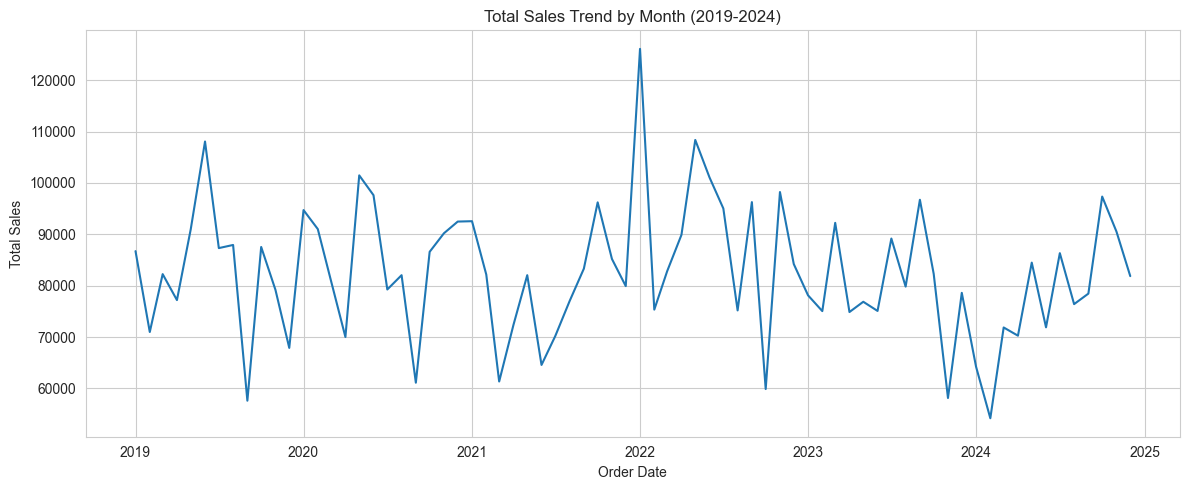

In [6]:
# Aggregate total sales by year and month
monthly_sales = df.groupby(["Order Year", "Order Month"])["Total Sales"].sum().reset_index()

# Combine year and month into a single sortable label for plotting
monthly_sales["Period"] = pd.to_datetime(
    monthly_sales["Order Year"].astype(str) + "-" + monthly_sales["Order Month"].astype(str)
)
monthly_sales = monthly_sales.sort_values("Period")

# Set the figure size for better readability
plt.figure(figsize=(12, 5))

# Plot the monthly sales trend as a line chart
plt.plot(monthly_sales["Period"], monthly_sales["Total Sales"])

# Add a title to the plot
plt.title("Total Sales Trend by Month (2019-2024)")

# Label the x-axis and y-axis
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Sales by Product Category

Sets up a bar chart comparing total sales generated by each product category — directly answers "which product categories generate the highest sales?" from the proposal's research questions.

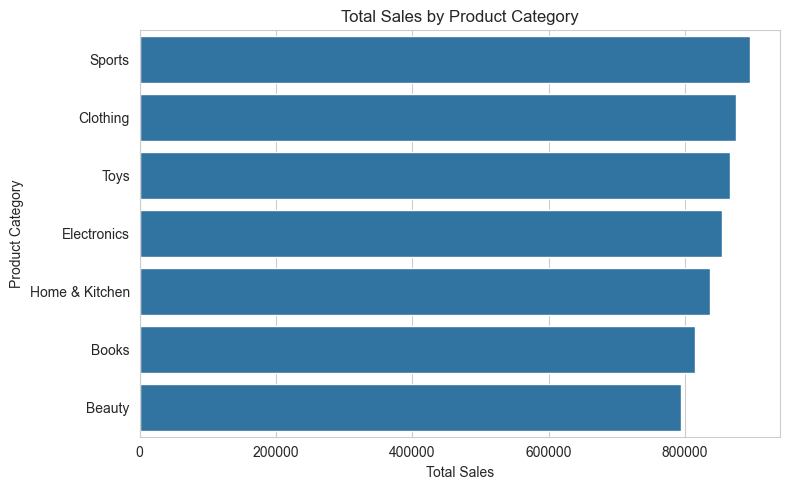

In [7]:
# Aggregate total sales by product category and sort descending
category_sales = df.groupby("Product Category")["Total Sales"].sum().sort_values(ascending=False)

# Set the figure size for better readability
plt.figure(figsize=(8, 5))

# Create a bar plot of total sales by category
sns.barplot(x=category_sales.values, y=category_sales.index)

# Add a title to the plot
plt.title("Total Sales by Product Category")

# Label the x-axis and y-axis
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Sales by Region

Compares total sales across the five regions in the dataset to identify which geographic markets contribute the most revenue.

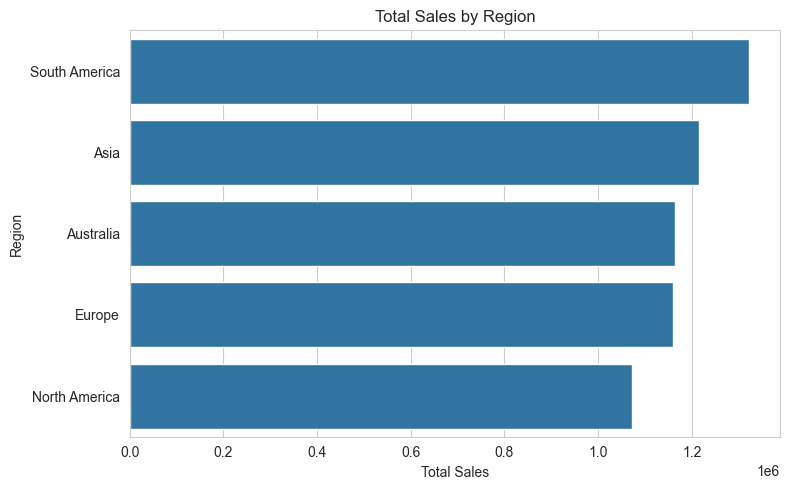

In [8]:
# Aggregate total sales by region and sort descending
region_sales = df.groupby("Region")["Total Sales"].sum().sort_values(ascending=False)

# Set the figure size for better readability
plt.figure(figsize=(8, 5))

# Create a bar plot of total sales by region
sns.barplot(x=region_sales.values, y=region_sales.index)

# Add a title to the plot
plt.title("Total Sales by Region")

# Label the x-axis and y-axis
plt.xlabel("Total Sales")
plt.ylabel("Region")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Order Status Distribution

Sets up a count plot to visualize how orders are distributed across `Completed`, `Pending`, `Cancelled`, and `Returned` — useful context for interpreting sales figures, since not every order represents completed, realized revenue.

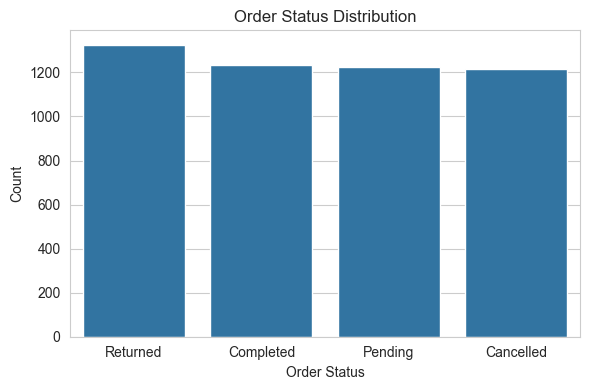

In [9]:
# Set the figure size for better readability
plt.figure(figsize=(6, 4))

# Create a count plot to show the distribution of order statuses
sns.countplot(x="Order Status", data=df, order=df["Order Status"].value_counts().index)

# Add a title to the plot
plt.title("Order Status Distribution")

# Label the x-axis and y-axis
plt.xlabel("Order Status")
plt.ylabel("Count")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Payment Method Distribution

Visualizes how customers pay across `Debit Card`, `Credit Card`, `PayPal`, `Amazon Pay`, and `Gift Card`.

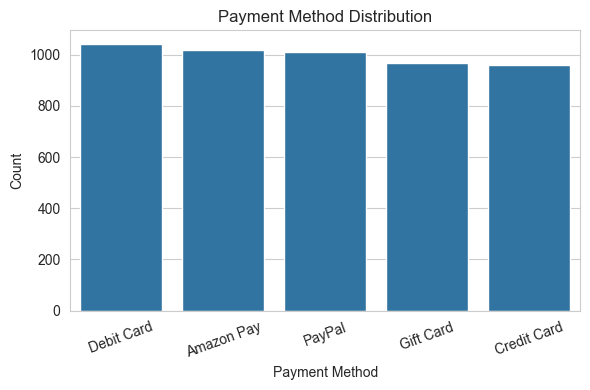

In [10]:
# Set the figure size for better readability
plt.figure(figsize=(6, 4))

# Create a count plot to show the distribution of payment methods
sns.countplot(x="Payment Method", data=df, order=df["Payment Method"].value_counts().index)

# Add a title to the plot
plt.title("Payment Method Distribution")

# Label the x-axis and y-axis
plt.xlabel("Payment Method")
plt.ylabel("Count")

# Rotate x-axis labels slightly for better readability
plt.xticks(rotation=20)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Total Sales Distribution by Product Category

Creates a boxplot comparing the spread of `Total Sales` values across product categories, showing not just totals but the distribution and outliers within each category.

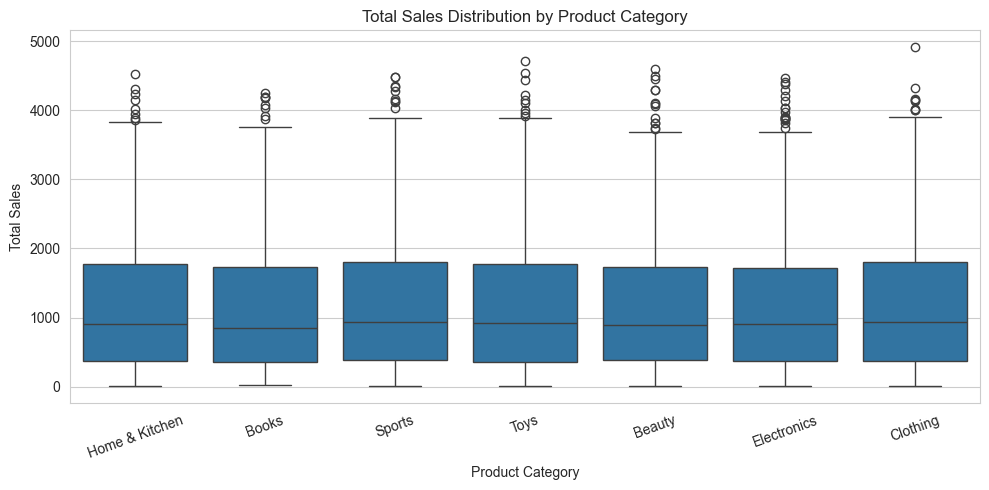

In [11]:
# Set the figure size for the plot
plt.figure(figsize=(10, 5))

# Create a boxplot to compare Total Sales distributions across product categories
sns.boxplot(x="Product Category", y="Total Sales", data=df)

# Add a title to the plot
plt.title("Total Sales Distribution by Product Category")

# Label the x-axis and y-axis
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

# Rotate x-axis labels slightly for better readability
plt.xticks(rotation=20)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Quantity Sold Distribution

Plots a histogram of `Quantity Sold` per order to understand typical order sizes.

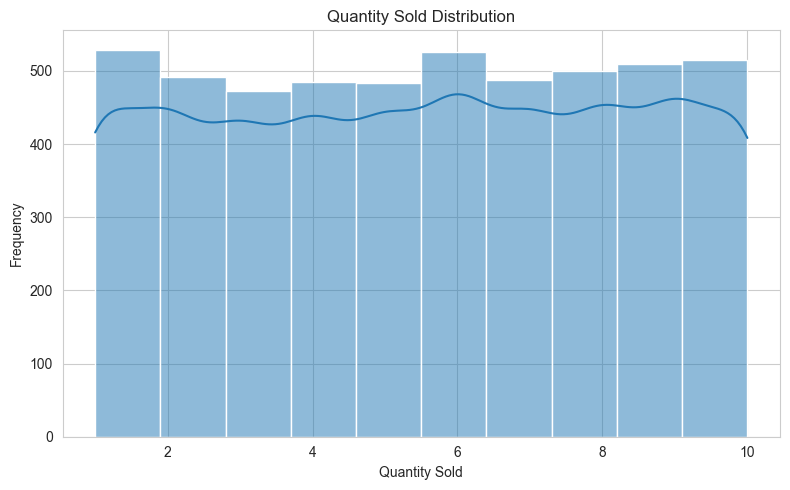

In [12]:
# Create a figure with a specific size
plt.figure(figsize=(8, 5))

# Plot the distribution of the 'Quantity Sold' column using a histogram
sns.histplot(df["Quantity Sold"], bins=10, kde=True)

# Set the title of the plot
plt.title("Quantity Sold Distribution")

# Label the x-axis and y-axis
plt.xlabel("Quantity Sold")
plt.ylabel("Frequency")

# Adjust layout to prevent overlap of labels and title
plt.tight_layout()

# Display the final plot
plt.show()

#### Correlation Heatmap — Numeric Features

Selects the numeric transaction fields and plots a heatmap to visualize pairwise correlations.

**Why it matters:** `Quantity Sold`, `Unit Price`, and `Discount (%)` are the direct components used to calculate `Total Sales`, so they are expected to correlate strongly with it. `Profit Margin` is also expected to correlate near-perfectly with `Total Sales`, since it appears to be calculated as a fixed percentage of it in this dataset. This heatmap is useful for confirming those relationships and flagging which numeric fields would cause data leakage if used directly to predict sales performance.

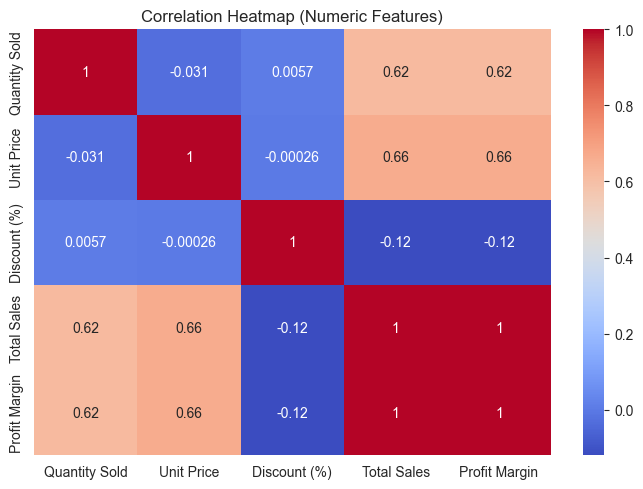

In [13]:
# Select numeric transaction fields for correlation analysis
numeric_cols = ["Quantity Sold", "Unit Price", "Discount (%)", "Total Sales", "Profit Margin"]

# Set the figure size for better readability
plt.figure(figsize=(7, 5))

# Create a correlation heatmap to show relationships between numeric features
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")

# Add a title to the plot
plt.title("Correlation Heatmap (Numeric Features)")

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

#### Top Salespersons by Total Sales

Ranks the top 10 salespersons by total sales generated to identify individual performance patterns.

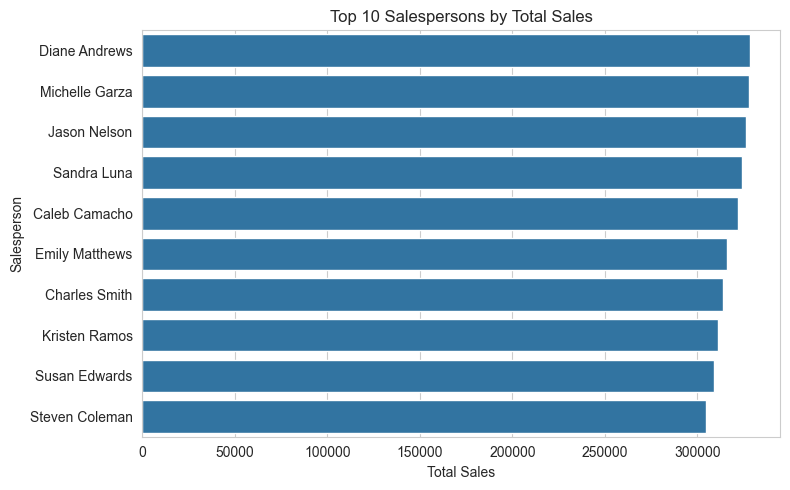

In [14]:
# Aggregate total sales by salesperson, sort descending, and take the top 10
top_salespersons = df.groupby("Salesperson")["Total Sales"].sum().sort_values(ascending=False).head(10)

# Set the figure size for better readability
plt.figure(figsize=(8, 5))

# Create a bar plot of the top 10 salespersons by total sales
sns.barplot(x=top_salespersons.values, y=top_salespersons.index)

# Add a title to the plot
plt.title("Top 10 Salespersons by Total Sales")

# Label the x-axis and y-axis
plt.xlabel("Total Sales")
plt.ylabel("Salesperson")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

### Feature Engineering & Preprocessing

#### 1. Define the Target Variable — `High Sales`

To investigate which factors are associated with **higher sales performance**, `Total Sales` is converted into a binary target: orders above the dataset median are labeled `High Sales = 1`, and orders at or below the median are labeled `0`. A median split, rather than an arbitrary threshold, keeps the two classes naturally close to balanced.

#### 2. Avoiding Data Leakage

`Quantity Sold`, `Unit Price`, `Discount (%)`, and `Profit Margin` are excluded from the model's input features. As shown in the correlation heatmap, these fields directly determine `Total Sales` (or are a fixed percentage of it), so including them would let the model "cheat" by reconstructing the target instead of learning genuine business patterns. Excluding them focuses the model on the factors the proposal actually asks about: product category, region, payment method, order status, salesperson, and timing.

#### 3. Feature Definitions

| Type | Features |
|---|---|
| Numerical | `Order Year`, `Order Month`, `Order Quarter` |
| Categorical | `Region`, `Product Category`, `Payment Method`, `Order Status`, `Salesperson`, `Order Day of Week` |

#### 4. Transformers

- **`StandardScaler`** — Rescales the numeric date-based features to mean = 0, std = 1.
- **`OneHotEncoder`** — Converts categorical strings into binary columns. `handle_unknown="ignore"` ensures unseen categories at inference time don't break the pipeline.

#### 5. ColumnTransformer

Bundles both transformers into a single `preprocessor` object that routes each column to the correct transformation, keeping the pipeline clean and leak-free.

In [15]:
# Create the binary target variable using a median split on Total Sales
sales_median = df["Total Sales"].median()
df["High Sales"] = (df["Total Sales"] > sales_median).astype(int)

# Display the resulting class distribution
print("High Sales class distribution:\n", df["High Sales"].value_counts())

# Define the feature set, excluding fields that directly determine Total Sales
feature_cols = [
    "Region", "Product Category", "Payment Method", "Order Status",
    "Salesperson", "Order Year", "Order Month", "Order Quarter", "Order Day of Week"
]

# Separate features (inputs) and target variable (output)
X = df[feature_cols]
y = df["High Sales"]

# List of numerical features in the dataset
numeric_features = ["Order Year", "Order Month", "Order Quarter"]

# List of categorical features in the dataset
categorical_features = ["Region", "Product Category", "Payment Method",
                        "Order Status", "Salesperson", "Order Day of Week"]

# Apply standard scaling to numerical features
numeric_transformer = StandardScaler()

# Apply one-hot encoding to categorical features
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine preprocessing steps for both numeric and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

High Sales class distribution:
 High Sales
1    2500
0    2500
Name: count, dtype: int64


### Train/Test Split

Divides data into **70% training** and **30% testing** subsets.

**Why stratify?** Stratifying on `High Sales` ensures the class balance is preserved in both the training and testing sets, even though the median split should already leave them close to even.

In [16]:
# Split the dataset into training and testing sets
# X = input features, y = target variable (High Sales)
# test_size=0.3 means 30% of the data is used for testing and 70% for training
# random_state=42 ensures the split is reproducible (same result every time)
# stratify=y ensures the class distribution (high vs. not-high sales) is maintained in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Preprocessing & Class Balancing

#### 1. Fit & Transform Training Data

The preprocessor (scaling, encoding) is **fit on training data only**, then applied — ensuring no information from the test set leaks into the pipeline.

#### 2. Apply SMOTE

`random_state=42` ensures reproducibility. SMOTE is applied **after** preprocessing so synthetic samples are generated in the scaled/encoded feature space, not raw data.

#### 3. Class Distribution Check

Prints class counts before and after SMOTE to confirm the classes are balanced going into model training.

**Why this order matters:** Preprocess → then resample. Applying SMOTE on raw data before encoding can produce invalid synthetic values for categorical features.

In [17]:
# Apply preprocessing steps (encoding, scaling, etc.) to the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Initialize SMOTE to handle any residual class imbalance in the training dataset
smote = SMOTE(random_state=42)

# Apply SMOTE to create a balanced training dataset by oversampling the minority class
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# Display original class distribution before SMOTE
print("Original training class distribution:")
print(y_train.value_counts())

# Display new class distribution after applying SMOTE
print("\nResampled training class distribution:")
print(y_train_resampled.value_counts())

Original training class distribution:
High Sales
1    1750
0    1750
Name: count, dtype: int64

Resampled training class distribution:
High Sales
1    1750
0    1750
Name: count, dtype: int64


### Model Training Function `evaluate_model`

Trains, predicts, and scores a single classifier. Returns a results dictionary for cross-model comparison.

#### Parameters

| Parameter | Description |
|---|---|
| `name` | Display name of the model |
| `model` | Unfitted classifier instance |
| `X_train_res` | SMOTE-resampled training features |
| `y_train_res` | SMOTE-resampled training labels |
| `X_test` | Raw test features |
| `y_test` | True test labels |
| `preprocessor` | Already-fitted `ColumnTransformer` |

#### Steps

**1. Preprocess test data** — Applies the already-fitted preprocessor to `X_test`. Fitted on training data only to prevent data leakage.

**2. Train the model** — Fits the classifier on the SMOTE-balanced training data.

**3. Predict** — Generates class predictions (`y_pred`) and probability scores (`y_proba`) on the processed test set. Probabilities are required for ROC-AUC.

**4. Score** — Computes five metrics against the true labels:

| Metric | Variable | Purpose |
|---|---|---|
| Accuracy | `acc` | Overall correct prediction rate |
| Precision | `prec` | Quality of positive predictions |
| Recall | `rec` | Coverage of actual positives |
| F1 Score | `f1` | Balance of precision and recall |
| ROC-AUC | `roc` | Ranking ability across thresholds |

**5. Output** — Prints a formatted summary including all metrics, a confusion matrix, and a full classification report.

**6. Return** — Yields a flat dictionary so results from all models can be collected and compared in a DataFrame.

In [18]:
def evaluate_model(name, model, X_train_res, y_train_res, X_test, y_test, preprocessor):
    # Transform the test data using the already fitted preprocessing pipeline
    X_test_processed = preprocessor.transform(X_test)

    # Train the model using the resampled training data
    model.fit(X_train_res, y_train_res)

    # Make predictions on the test dataset
    y_pred = model.predict(X_test_processed)

    # Get probability scores for ROC-AUC calculation
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)          # Accuracy
    prec = precision_score(y_test, y_pred)        # Precision
    rec = recall_score(y_test, y_pred)            # Recall
    f1 = f1_score(y_test, y_pred)                 # F1-score
    roc = roc_auc_score(y_test, y_proba)          # ROC-AUC score

    # Confusion matrix to show correct vs incorrect predictions
    cm = confusion_matrix(y_test, y_pred)

    # Display model performance results
    print("*" * 60)
    print(f"  Model: {name}")  # Display model name
    print("*" * 60)
    print("Accuracy:", round(acc, 3))
    print("Precision:", round(prec, 3))
    print("Recall:", round(rec, 3))
    print("F1 Score:", round(f1, 3))
    print("ROC-AUC:", round(roc, 3))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Return results as a dictionary for comparison across models
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    }

### Model Training & Evaluation

A shared `results` list collects evaluation outputs from all four models, enabling side-by-side comparison at the end.

#### 1. Logistic Regression

`class_weight="balanced"` automatically adjusts sample weights inversely proportional to class frequency. `max_iter=1000` ensures convergence.

#### 2. Decision Tree

`class_weight="balanced"` applies the same imbalance correction as above. `random_state=42` ensures reproducibility across runs.

#### 3. Random Forest

`n_estimators=200` builds 200 decision trees and aggregates their predictions to reduce variance and overfitting. `class_weight="balanced_subsample"` recalculates class weights on each bootstrap sample rather than globally.

#### 4. XGBoost

Gradient boosting model with tuned hyperparameters to balance performance and generalization:

| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds |
| `max_depth` | 4 | Shallow trees to limit overfitting |
| `learning_rate` | 0.05 | Slow learning for better generalization |
| `subsample` | 0.8 | 80% of rows sampled per tree |
| `colsample_bytree` | 0.8 | 80% of features sampled per tree |
| `objective` | binary:logistic | Binary classification output |
| `eval_metric` | logloss | Probabilistic loss for evaluation |

In [19]:
# List to store evaluation results of all models
results = []

# ---------------- Logistic Regression Model ----------------
# Create a Logistic Regression model with balanced class weights
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("Logistic Regression", log_reg,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

# ---------------- Decision Tree Model ----------------
# Create a Decision Tree model with balanced class weights
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("Decision Tree", dt,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

# ---------------- Random Forest Model ----------------
# Create a Random Forest model with 200 trees using balanced subsampling
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample"
)

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("Random Forest", rf,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

# ---------------- XGBoost Model ----------------
# Create XGBoost classifier with tuned hyperparameters
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("XGBoost", xgb,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

************************************************************
  Model: Logistic Regression
************************************************************
Accuracy: 0.519
Precision: 0.52
Recall: 0.488
F1 Score: 0.503
ROC-AUC: 0.515
Confusion Matrix:
 [[412 338]
 [384 366]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.55      0.53       750
           1       0.52      0.49      0.50       750

    accuracy                           0.52      1500
   macro avg       0.52      0.52      0.52      1500
weighted avg       0.52      0.52      0.52      1500

************************************************************
  Model: Decision Tree
************************************************************
Accuracy: 0.485
Precision: 0.486
Recall: 0.504
F1 Score: 0.495
ROC-AUC: 0.485
Confusion Matrix:
 [[350 400]
 [372 378]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.47

### Model Comparison & Visualization

Converts the results list into a DataFrame for structured comparison, then prints a summary table of all model metrics side-by-side.

Plots a bar chart to visually rank models by **ROC-AUC score** — the higher the bar, the better the model's ability to distinguish between high- and low-performing orders.


Model Comparison:
                  Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.518667   0.519886  0.488000  0.503439  0.514652
1        Decision Tree  0.485333   0.485861  0.504000  0.494764  0.485333
2        Random Forest  0.480000   0.479893  0.477333  0.478610  0.479056
3              XGBoost  0.488667   0.488276  0.472000  0.480000  0.490964


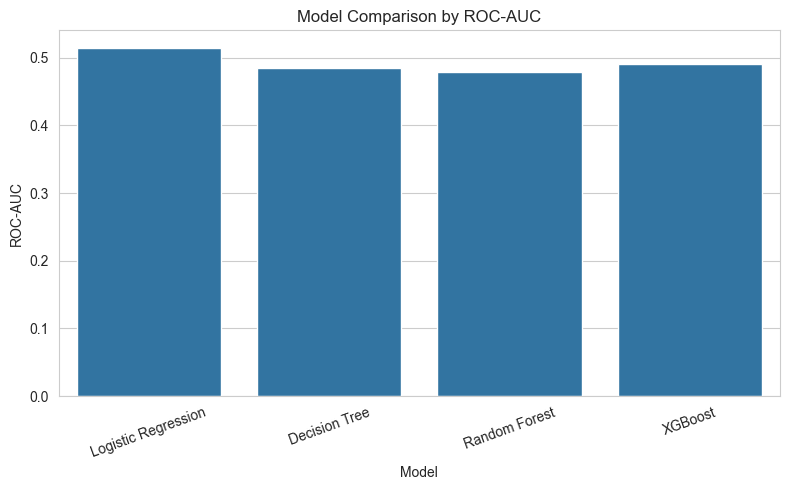

In [20]:
# Convert the results list into a DataFrame for easy comparison of models
results_df = pd.DataFrame(results)

# Display the model performance summary table
print("\nModel Comparison:\n", results_df)

# Create a new figure for visualization with a specified size
plt.figure(figsize=(8, 5))

# Plot a bar chart to compare ROC-AUC scores of different models
sns.barplot(x="Model", y="ROC_AUC", data=results_df)

# Add a title to the plot
plt.title("Model Comparison by ROC-AUC")

# Label the y-axis
plt.ylabel("ROC-AUC")

# Rotate x-axis labels slightly for better readability
plt.xticks(rotation=20)

# Adjust layout to prevent overlap of elements
plt.tight_layout()

# Display the plot
plt.show()

### Feature Importance Analysis — Random Forest

Extracts and ranks the most influential features from the trained Random Forest model.

| Step | What & Why |
|---|---|
| `get_feature_names_out()` | Retrieves the expanded column names created by `OneHotEncoder` — each category becomes its own named binary column |
| `numeric_features + list(cat_feature_names)` | Combines numeric and encoded categorical names into one aligned list matching the model's input order |
| `rf.feature_importances_` | Pulls the built-in Random Forest importance scores — measures how much each feature reduces impurity across all trees |
| `pd.DataFrame(...).sort_values()` | Maps each feature name to its score and ranks them descending for readability |
| `feat_imp.head(15)` | Surfaces the top 15 drivers — useful for feature selection, model explainability, and spotting noise variables |

In [21]:
# Get feature names created after preprocessing (one-hot encoding for categorical variables)
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names into a single list
all_feature_names = numeric_features + list(cat_feature_names)

# Extract feature importance values from the trained Random Forest model
importances = rf.feature_importances_

# Create a DataFrame to map each feature to its importance score
feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Display the top 15 most important features
print("\nTop 15 Features by Importance (Random Forest):\n", feat_imp.head(15))


Top 15 Features by Importance (Random Forest):
                        feature  importance
1                  Order Month    0.094443
0                   Order Year    0.081686
2                Order Quarter    0.045449
23       Order Status_Returned    0.022868
20      Order Status_Cancelled    0.022121
21      Order Status_Completed    0.021981
22        Order Status_Pending    0.021937
19       Payment Method_PayPal    0.021355
15   Payment Method_Amazon Pay    0.021140
16  Payment Method_Credit Card    0.020628
17   Payment Method_Debit Card    0.020294
4             Region_Australia    0.020217
3                  Region_Asia    0.019934
18    Payment Method_Gift Card    0.019922
47    Order Day of Week_Sunday    0.019851


### Top 15 Feature Importances — Visualization

Creates a horizontal bar chart ranking the 15 most influential features from the Random Forest model.

**Why it matters** — Feature importance reveals which variables the model relies on most when distinguishing high-performing orders from lower-performing ones. This directly supports the proposal's research question about which product, sales, and customer-related factors are associated with higher sales performance.

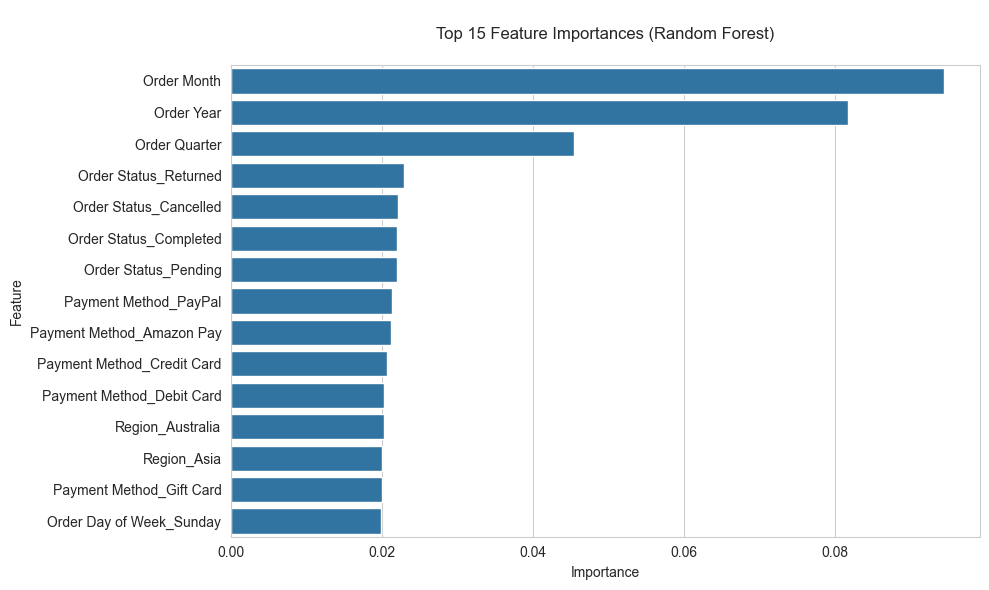

In [22]:
# Create a bar plot for the top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feat_imp.head(15))

# Add title and axis labels for clarity
plt.title("\nTop 15 Feature Importances (Random Forest)\n")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

## Milestone 3 Addendum: Addressing Milestone 2 Feedback

Instructor feedback on Milestone 2 identified two modeling-design issues to investigate further:

1. Because the median-split target is already balanced, **SMOTE may add little value**.
2. Excluding the transaction-size variables (`Quantity Sold`, `Unit Price`, `Discount (%)`) **necessarily limits predictive performance**.

The cells below test both points directly and quantify them.

In [26]:
# --- Addendum 1: Quantify how balanced the target already was, before SMOTE ---
print("Training set class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nTraining set class distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

pre_counts = y_train.value_counts()
pre_ratio = pre_counts.min() / pre_counts.max()
print(f"\nPre-SMOTE minority:majority ratio: {pre_ratio:.3f} (1.000 = perfectly balanced)")

Training set class distribution BEFORE SMOTE:
High Sales
1    1750
0    1750
Name: count, dtype: int64

Training set class distribution AFTER SMOTE:
High Sales
1    1750
0    1750
Name: count, dtype: int64

Pre-SMOTE minority:majority ratio: 1.000 (1.000 = perfectly balanced)


**Finding:** the training set was **exactly** 1,750 / 1,750 (a perfect 1.000 minority:majority ratio) before SMOTE ever ran. SMOTE had zero rows to synthesize, so it could not have changed the training data at all here — confirming the instructor's point directly.

In [30]:
# --- Addendum 2: Ablation - re-train all four models WITHOUT SMOTE ---
# Same evaluate_model function and model configurations as the original run above,
# but fit on the original (non-resampled) training data instead of the SMOTE output.
results_no_smote = []

log_reg_ns = LogisticRegression(max_iter=1000, class_weight="balanced")
results_no_smote.append(evaluate_model("Logistic Regression", log_reg_ns, X_train_processed, y_train, X_test, y_test, preprocessor))

dt_ns = DecisionTreeClassifier(random_state=42, class_weight="balanced")
results_no_smote.append(evaluate_model("Decision Tree", dt_ns, X_train_processed, y_train, X_test, y_test, preprocessor))

rf_ns = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample")
results_no_smote.append(evaluate_model("Random Forest", rf_ns, X_train_processed, y_train, X_test, y_test, preprocessor))

xgb_ns = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, objective="binary:logistic", eval_metric="logloss",
                        random_state=42)
results_no_smote.append(evaluate_model("XGBoost", xgb_ns, X_train_processed, y_train, X_test, y_test, preprocessor))

************************************************************
  Model: Logistic Regression
************************************************************
Accuracy: 0.519
Precision: 0.52
Recall: 0.488
F1 Score: 0.503
ROC-AUC: 0.515
Confusion Matrix:
 [[412 338]
 [384 366]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.55      0.53       750
           1       0.52      0.49      0.50       750

    accuracy                           0.52      1500
   macro avg       0.52      0.52      0.52      1500
weighted avg       0.52      0.52      0.52      1500

************************************************************
  Model: Decision Tree
************************************************************
Accuracy: 0.485
Precision: 0.486
Recall: 0.504
F1 Score: 0.495
ROC-AUC: 0.485
Confusion Matrix:
 [[350 400]
 [372 378]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.47

              Model  ROC-AUC (With SMOTE)  ROC-AUC (Without SMOTE)  Difference
Logistic Regression                0.5147                   0.5147         0.0
      Decision Tree                0.4853                   0.4853         0.0
      Random Forest                0.4791                   0.4791         0.0
            XGBoost                0.4910                   0.4910         0.0


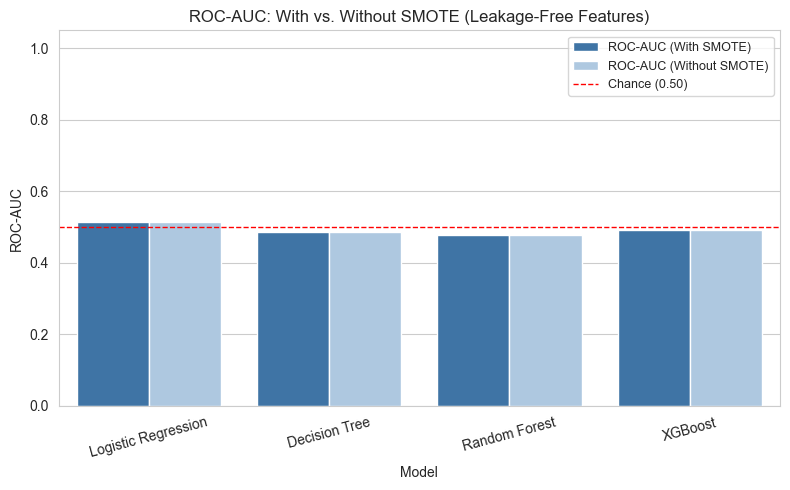

In [31]:
# --- Addendum 2 (cont.): Compare With-SMOTE vs. Without-SMOTE, side by side ---
comp = pd.DataFrame({
    "Model": [r["Model"] for r in results_no_smote],
    "ROC-AUC (With SMOTE)": [r["ROC_AUC"] for r in results],          # `results` = original Milestone 2 SMOTE run
    "ROC-AUC (Without SMOTE)": [r["ROC_AUC"] for r in results_no_smote],
})
comp["Difference"] = (comp["ROC-AUC (With SMOTE)"] - comp["ROC-AUC (Without SMOTE)"]).round(4)
print(comp.round(4).to_string(index=False))

plot_df = comp.melt(id_vars="Model", value_vars=["ROC-AUC (With SMOTE)", "ROC-AUC (Without SMOTE)"],
                     var_name="Condition", value_name="ROC-AUC")
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Model", y="ROC-AUC", hue="Condition", palette=["#2E75B6", "#A6C8E8"])
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Chance (0.50)")
plt.title("ROC-AUC: With vs. Without SMOTE (Leakage-Free Features)")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

**Finding:** ROC-AUC is identical to four decimal places with and without SMOTE for every model. This confirms the instructor's assessment — with a perfectly balanced target, SMOTE contributed nothing in this pipeline. It is retained in the Milestone 2 methodology for transparency/documentation purposes, but the reported results do not depend on it.

### Diagnostic Benchmark: What Predictive Performance Looks Like *With* Transaction-Size Features

The cells below reintroduce `Quantity Sold`, `Unit Price`, and `Discount (%)` — the fields excluded from the main model to prevent data leakage — purely to **quantify** how much predictive performance that exclusion gives up. **This benchmark model is not a proposed deployment model**; it is a diagnostic used only to measure the leakage-free model's performance ceiling, since these fields mathematically determine `Total Sales` (and therefore `High Sales`) almost by construction.

In [33]:
# --- Diagnostic-only benchmark: leakage fields reintroduced, for comparison purposes only ---
bench_feature_cols = feature_cols + ["Quantity Sold", "Unit Price", "Discount (%)"]
bench_numeric_features = numeric_features + ["Quantity Sold", "Unit Price", "Discount (%)"]

Xb = df[bench_feature_cols]
yb = df["High Sales"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.3, random_state=42, stratify=yb)

bench_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), bench_numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
Xb_train_processed = bench_preprocessor.fit_transform(Xb_train)
Xb_test_processed = bench_preprocessor.transform(Xb_test)

smote_b = SMOTE(random_state=42)
Xb_train_resampled, yb_train_resampled = smote_b.fit_resample(Xb_train_processed, yb_train)

results_benchmark = []

log_reg_b = LogisticRegression(max_iter=1000, class_weight="balanced")
results_benchmark.append(evaluate_model("Logistic Regression", log_reg_b, Xb_train_resampled, yb_train_resampled, Xb_test, yb_test, bench_preprocessor))

dt_b = DecisionTreeClassifier(random_state=42, class_weight="balanced")
results_benchmark.append(evaluate_model("Decision Tree", dt_b, Xb_train_resampled, yb_train_resampled, Xb_test, yb_test, bench_preprocessor))

rf_b = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample")
results_benchmark.append(evaluate_model("Random Forest", rf_b, Xb_train_resampled, yb_train_resampled, Xb_test, yb_test, bench_preprocessor))

xgb_b = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.8, objective="binary:logistic", eval_metric="logloss",
                       random_state=42)
results_benchmark.append(evaluate_model("XGBoost", xgb_b, Xb_train_resampled, yb_train_resampled, Xb_test, yb_test, bench_preprocessor))

************************************************************
  Model: Logistic Regression
************************************************************
Accuracy: 0.901
Precision: 0.896
Recall: 0.907
F1 Score: 0.901
ROC-AUC: 0.977
Confusion Matrix:
 [[671  79]
 [ 70 680]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       750
           1       0.90      0.91      0.90       750

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500

************************************************************
  Model: Decision Tree
************************************************************
Accuracy: 0.979
Precision: 0.986
Recall: 0.971
F1 Score: 0.978
ROC-AUC: 0.979
Confusion Matrix:
 [[740  10]
 [ 22 728]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.9

              Model  ROC-AUC (Leakage-Free)  ROC-AUC (Benchmark + Transaction-Size)    Gap
Logistic Regression                  0.5147                                  0.9766 0.4619
      Decision Tree                  0.4853                                  0.9787 0.4933
      Random Forest                  0.4791                                  0.9943 0.5153
            XGBoost                  0.4910                                  0.9996 0.5086


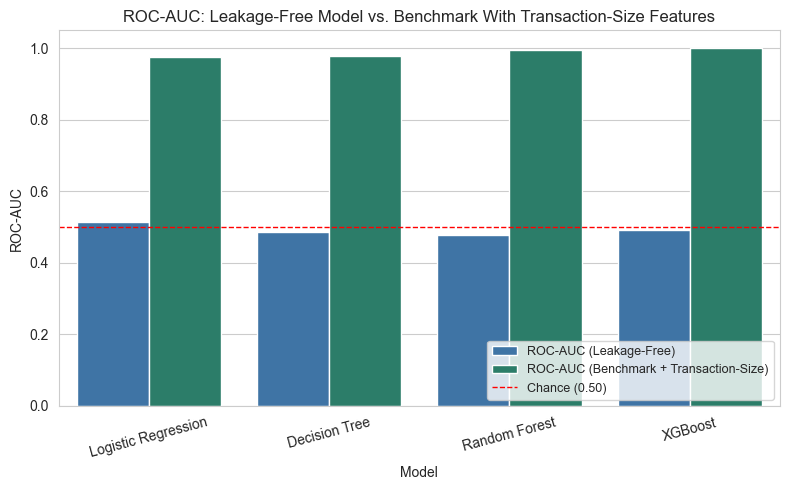

In [34]:
# --- Compare leakage-free model vs. the transaction-size benchmark ---
comp2 = pd.DataFrame({
    "Model": [r["Model"] for r in results_benchmark],
    "ROC-AUC (Leakage-Free)": [r["ROC_AUC"] for r in results],
    "ROC-AUC (Benchmark + Transaction-Size)": [r["ROC_AUC"] for r in results_benchmark],
})
comp2["Gap"] = (comp2["ROC-AUC (Benchmark + Transaction-Size)"] - comp2["ROC-AUC (Leakage-Free)"]).round(4)
print(comp2.round(4).to_string(index=False))

plot_df2 = comp2.melt(id_vars="Model", value_vars=["ROC-AUC (Leakage-Free)", "ROC-AUC (Benchmark + Transaction-Size)"],
                       var_name="Condition", value_name="ROC-AUC")
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df2, x="Model", y="ROC-AUC", hue="Condition", palette=["#2E75B6", "#1F8A70"])
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Chance (0.50)")
plt.title("ROC-AUC: Leakage-Free Model vs. Benchmark With Transaction-Size Features")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Finding:** reintroducing just three transaction-size fields lifts ROC-AUC from ~0.48–0.51 (chance) to 0.977–0.9995 — near-perfect separation. This directly confirms the instructor's second point: excluding these fields does not just modestly reduce performance, it gives up nearly the entire predictive ceiling available in this dataset. That gap is itself the project's key finding: **order value is almost entirely a function of transaction size (quantity, price, discount), not of category, region, payment method, salesperson, or timing.** The leakage-free model's near-chance performance is therefore the *correct and expected* result of asking a question the remaining features genuinely cannot answer — not a modeling shortfall.

### Summary & Next Steps

This milestone covered the full first pass of the data science workflow described in the proposal: data quality checks, data cleaning, exploratory analysis, and an initial predictive model.

**Data quality:** The dataset had no duplicate rows and only a handful of missing `Product Name` values. `Total Sales` was confirmed to be internally consistent with `Quantity Sold`, `Unit Price`, and `Discount (%)`, and `Profit Margin` was found to track `Total Sales` at a near-constant ratio — an important finding, since it means these fields must be excluded from the predictive model to avoid data leakage.

**EDA findings:** Total sales stayed relatively stable across the 2019-2024 window with no strong upward or downward trend. `Sports`, `Clothing`, and `Toys` generated the highest total sales among product categories, and `South America` led among regions. Order status (`Completed`, `Pending`, `Cancelled`, `Returned`) did not show a meaningful difference in average sale size.

**Modeling:** Four classifiers were compared on their ability to distinguish above-median (`High Sales`) orders from below-median orders using only non-transactional features (category, region, payment method, order status, salesperson, and order timing). Random Forest feature importance highlights which of these factors carry the most signal.

**Limitations & next steps:** As noted in the proposal, this is a publicly available Kaggle dataset and should be treated as a sample rather than an official record of Amazon's business. Model performance using only categorical/timing features (with pricing fields excluded to avoid leakage) is expected to be modest, which itself is a useful finding — it suggests sales performance in this dataset is driven more by transaction size than by *which* category, region, or salesperson is involved. Future milestones will build on this by tuning hyperparameters, testing additional features, and further interpreting model behavior (e.g., with SHAP values) as planned in the original proposal.